# Graphs for Data Visualization
Code authors: Caroline Parent & Hasti Honari

In [60]:
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy.optimize import curve_fit 


## Load dataset

In [124]:
# Combine xlsx of experiments in one csv
#Remove rows with missing data
def clean_dataframe(df, label=None):
    """Clean dataframe by converting whitespace-only strings to NaN,
       dropping completely empty columns and rows with any NaN. Return cleaned df.
    """
    before = df.shape[0]
    # Convert whitespace-only strings to NaN
    df = df.replace(r'^\s*$', np.nan, regex=True)
    # Remove completely empty columns
    df = df.dropna(axis=1, how="all")
    # Remove rows with any NaN left
    df = df.dropna(how="any").reset_index(drop=True)
    after = df.shape[0]
    removed = before - after
    if label:
        print(f"Cleaned {label}: removed {removed} rows ({before} -> {after})")
    else:
        print(f"Cleaned DataFrame: removed {removed} rows ({before} -> {after})")
    return df


def normalize_file_to_name(df, label=None):
    """If a DataFrame has a 'File' column, create/replace a 'Name' column
    with the normalized filename stem (no path, no extension, drop final
    short alphabetic channel tokens like 'BF'). Drops the original 'File'.
    """
    if 'File' not in df.columns:
        return df

    def _to_name(x):
        try:
            stem = Path(str(x)).stem
        except Exception:
            stem = str(x)
        parts = stem.split('_')
        # If last token looks like a channel (letters, short), drop it
        if len(parts) > 1 and parts[-1].isalpha() and len(parts[-1]) <= 4:
            parts = parts[:-1]
        return '_'.join(parts)

    df = df.copy()
    df['Name'] = df['File'].astype(str).map(_to_name)
    n = df['Name'].notna().sum()
    if label:
        print(f"{label}: converted {n} 'File' entries -> 'Name'")
    else:
        print(f"Converted {n} 'File' entries -> 'Name'")
    df = df.drop(columns=['File'])
    return df

# Build DataFrames from two Excel files
def build_dataframes(file_path_incubate, file_path_immediate):
    """Create incubate, immediate, and control DataFrames from two files"""
    all_sheets_incubate = pd.read_excel(file_path_incubate, sheet_name=None, decimal=',')
    all_sheets_immediate = pd.read_excel(file_path_immediate, sheet_name=None, decimal=',')

    # --- Create incubate ---
    dfs_incubate = []
    total_removed_inc = 0
    for name, df in all_sheets_incubate.items():
        if name == "Tube 1":
            continue
        before_n = df.shape[0]
        # Add sheet name column so each row knows its source sheet
        df = df.copy()
        df['Sheet'] = name
        df_proc = normalize_file_to_name(df, label=f"{Path(file_path_incubate).name} - sheet {name}")
        df_clean = clean_dataframe(df_proc, label=f"{Path(file_path_incubate).name} - sheet {name}")
        removed = before_n - df_clean.shape[0]
        total_removed_inc += removed
        if not df_clean.empty:
            dfs_incubate.append(df_clean)
    if dfs_incubate:
        df_incubate = pd.concat(dfs_incubate, ignore_index=True)
    else:
        df_incubate = pd.DataFrame()
    if total_removed_inc > 0:
        print(f"{Path(file_path_incubate).name}: total removed rows across sheets: {total_removed_inc}")

    # --- Create immediate ---
    dfs_immediate = []
    total_removed_imm = 0
    for name, df in all_sheets_immediate.items():
        if name == "Tube 1":
            continue
        before_n = df.shape[0]
        # Add sheet name column so each row knows its source sheet
        df = df.copy()
        df['Sheet'] = name
        df_proc = normalize_file_to_name(df, label=f"{Path(file_path_immediate).name} - sheet {name}")
        df_clean = clean_dataframe(df_proc, label=f"{Path(file_path_immediate).name} - sheet {name}")
        removed = before_n - df_clean.shape[0]
        total_removed_imm += removed
        if not df_clean.empty:
            dfs_immediate.append(df_clean)
    if dfs_immediate:
        df_immediate = pd.concat(dfs_immediate, ignore_index=True)
    else:
        df_immediate = pd.DataFrame()
    if total_removed_imm > 0:
        print(f"{Path(file_path_immediate).name}: total removed rows across sheets: {total_removed_imm}")

    # --- Create control ---
    dfs_control = []
    total_removed_control = 0
    if "Tube 1" in all_sheets_incubate:
        before_n = all_sheets_incubate["Tube 1"].shape[0]
        df = all_sheets_incubate["Tube 1"].copy()
        df['Sheet'] = "Tube 1"
        df_proc = normalize_file_to_name(df, label=f"{Path(file_path_incubate).name} - sheet Tube 1")
        df_clean = clean_dataframe(df_proc, label=f"{Path(file_path_incubate).name} - sheet Tube 1")
        removed = before_n - df_clean.shape[0]
        total_removed_control += removed
        if not df_clean.empty:
            dfs_control.append(df_clean)
    if "Tube 1" in all_sheets_immediate:
        before_n = all_sheets_immediate["Tube 1"].shape[0]
        df = all_sheets_immediate["Tube 1"].copy()
        df['Sheet'] = "Tube 1"
        df_proc = normalize_file_to_name(df, label=f"{Path(file_path_immediate).name} - sheet Tube 1")
        df_clean = clean_dataframe(df_proc, label=f"{Path(file_path_immediate).name} - sheet Tube 1")
        removed = before_n - df_clean.shape[0]
        total_removed_control += removed
        if not df_clean.empty:
            dfs_control.append(df_clean)
    if dfs_control:
        df_control = pd.concat(dfs_control, ignore_index=True)
    else:
        df_control = pd.DataFrame()
    if total_removed_control > 0:
        print(f"Control sheets: total removed rows across control sheets: {total_removed_control}")

    return df_incubate, df_immediate, df_control

SyntaxError: invalid syntax (192293993.py, line 171)

In [88]:
# Define all experiment paths for different cell lines
# Files are organized as: Final_data_inc_day0.xlsx, Final_data_inc_day1.xlsx, Final_data_inc_day2.xlsx
#                        Final_data_imm_day0.xlsx, Final_data_imm_day1.xlsx, Final_data_imm_day2.xlsx
all_experiments_paths = {
    "MCF7": {
        "Exp1": {
            "base_path": r"E:\Experiments\PTT\Spheroids\01072025_mcf7",
        },
        "Exp2": {
            "base_path": r"E:\Experiments\PTT\Spheroids\02062025_mcf7",
        },
        "Exp3": {
            "base_path": r"E:\Experiments\PTT\Spheroids\05052025",
        },
    },
    "MCF10": {
        "Exp1": {
            "base_path": r"E:\Experiments\PTT\Spheroids\01072025_mcf7",
        },
        "Exp2": {
            "base_path": r"E:\Experiments\PTT\Spheroids\02062025_mcf7\04062025 after laser",
        },
        "Exp3": {
            "base_path": r"E:\Experiments\PTT\Spheroids\05052025\07052025 after laser",
        },
    },
    "MDA": {
        "Exp1": {
            "base_path": r"E:\Experiments\PTT\Spheroids\01072025_mcf7",
        },
        "Exp2": {
            "base_path": r"E:\Experiments\PTT\Spheroids\02062025_mcf7\04062025 after laser",
        },
        "Exp3": {
            "base_path": r"E:\Experiments\PTT\Spheroids\05052025\07052025 after laser",
        },
    },
    "HS578T": {
        "Exp1": {
            "base_path": r"E:\Experiments\PTT\Spheroids\01072025_mcf7",
        },
        "Exp2": {
            "base_path": r"E:\Experiments\PTT\Spheroids\02062025_mcf7\04062025 after laser",
        },
        "Exp3": {
            "base_path": r"E:\Experiments\PTT\Spheroids\05052025\07052025 after laser",
        },
    },
    "PDX": {
        "Exp1": {
            "base_path": r"E:\Experiments\PTT\Spheroids\01072025_mcf7",
        },
        "Exp2": {
            "base_path": r"E:\Experiments\PTT\Spheroids\02062025_mcf7\04062025 after laser",
        },
        "Exp3": {
            "base_path": r"E:\Experiments\PTT\Spheroids\05052025\07052025 after laser",
        },
    },
    
}

# SELECT CELL LINE HERE
cell_line = "MCF7"
experiments_paths = all_experiments_paths[cell_line]
print(f"Running analysis for cell line: {cell_line}")

Running analysis for cell line: MCF7


In [126]:
# Collect all incubate and immediate DataFrames, add Experiment ID column

dfs_incubate_d2 = []
dfs_immediate_d2 = []
dfs_incubate_d1 = []
dfs_immediate_d1 = []


for i, (exp_name, paths) in enumerate(experiments_paths.items(), start=1):
    base_path = paths["base_path"]
    inc_path_d1 = f"{base_path}\\Final_data_inc_day1.xlsx"
    imm_path_d1 = f"{base_path}\\Final_data_imm_day1.xlsx"
    inc_path_d2 = f"{base_path}\\Final_data_inc_day2.xlsx"
    imm_path_d2 = f"{base_path}\\Final_data_imm_day2.xlsx"
    df_incubate_d1, df_immediate_d1, df_control_d1 = build_dataframes(inc_path_d1, imm_path_d1)
    df_incubate_d2, df_immediate_d2, df_control_d2 = build_dataframes(inc_path_d2, imm_path_d2)
    # Add Experiment ID column
    df_incubate_d2["Experiment ID"] = i
    df_immediate_d2["Experiment ID"] = i
    df_incubate_d1["Experiment ID"] = i
    df_immediate_d1["Experiment ID"] = i
    # Add Label column if Normalised alb exists
    if "Normalised alb" in df_incubate_d2.columns:
        df_incubate_d2["Label"] = np.where(df_incubate_d2["Normalised alb"] > 50, "Alive", "Dead")
    if "Normalised alb" in df_immediate_d2.columns:
        df_immediate_d2["Label"] = np.where(df_immediate_d2["Normalised alb"] > 50, "Alive", "Dead")
    dfs_incubate_d2.append(df_incubate_d2)
    dfs_immediate_d2.append(df_immediate_d2)
    dfs_incubate_d1.append(df_incubate_d1)
    dfs_immediate_d1.append(df_immediate_d1)

# Concatenate all experiments for each condition
df_incubate_all_d1 = pd.concat(dfs_incubate_d1, ignore_index=True)
df_immediate_all_d1 = pd.concat(dfs_immediate_d1, ignore_index=True)
df_incubate_all_d2 = pd.concat(dfs_incubate_d2, ignore_index=True)
df_immediate_all_d2 = pd.concat(dfs_immediate_d2, ignore_index=True)



Cleaned Final_data_inc_day1.xlsx - sheet Tube 4: removed 0 rows (20 -> 20)
Cleaned Final_data_inc_day1.xlsx - sheet Tube 3: removed 0 rows (21 -> 21)
Cleaned Final_data_inc_day1.xlsx - sheet Tube 2: removed 1 rows (20 -> 19)
Final_data_inc_day1.xlsx: total removed rows across sheets: 1
Cleaned Final_data_imm_day1.xlsx - sheet Tube 8: removed 0 rows (20 -> 20)
Cleaned Final_data_imm_day1.xlsx - sheet Tube 7: removed 0 rows (20 -> 20)
Cleaned Final_data_imm_day1.xlsx - sheet Tube 6: removed 0 rows (20 -> 20)
Cleaned Final_data_imm_day1.xlsx - sheet Tube 5: removed 0 rows (20 -> 20)
Cleaned Final_data_inc_day1.xlsx - sheet Tube 1: removed 3 rows (24 -> 21)
Control sheets: total removed rows across control sheets: 3
Cleaned Final_data_inc_day2.xlsx - sheet Tube 4: removed 3 rows (20 -> 17)
Cleaned Final_data_inc_day2.xlsx - sheet Tube 3: removed 3 rows (20 -> 17)
Cleaned Final_data_inc_day2.xlsx - sheet Tube 2: removed 2 rows (20 -> 18)
Final_data_inc_day2.xlsx: total removed rows across s

In [127]:
def fix_decimal_commas(value):
    """Convert a string with comma decimal separator to float."""
    if isinstance(value, str):
        value = value.replace(',', '.')
        try:
            return float(value)
        except ValueError:
            return value
    return value
df_incubate_all_d1 = df_incubate_all_d1.applymap(fix_decimal_commas)
df_immediate_all_d1 = df_immediate_all_d1.applymap(fix_decimal_commas)
df_incubate_all_d2 = df_incubate_all_d2.applymap(fix_decimal_commas)
df_immediate_all_d2 = df_immediate_all_d2.applymap(fix_decimal_commas)

save_folder = r"E:\Experiments\PTT\Spheroids\all data\mcf7"
# Save to CSV
df_incubate_all_d1.to_csv(f"{save_folder}\\combined_incubate_d1.csv", index=False)
df_immediate_all_d1.to_csv(f"{save_folder}\\combined_immediate_d1.csv",  index=False)
df_incubate_all_d2.to_csv(f"{save_folder}\\combined_incubate_d2.csv", index=False)
df_immediate_all_d2.to_csv(f"{save_folder}\\combined_immediate_d2.csv",  index=False)

C:\Users\MMBM-2024-L3\AppData\Local\Temp\ipykernel_27712\2638071838.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_incubate_all_d1 = df_incubate_all_d1.applymap(fix_decimal_commas)
C:\Users\MMBM-2024-L3\AppData\Local\Temp\ipykernel_27712\2638071838.py:11: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_immediate_all_d1 = df_immediate_all_d1.applymap(fix_decimal_commas)
C:\Users\MMBM-2024-L3\AppData\Local\Temp\ipykernel_27712\2638071838.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_incubate_all_d2 = df_incubate_all_d2.applymap(fix_decimal_commas)
C:\Users\MMBM-2024-L3\AppData\Local\Temp\ipykernel_27712\2638071838.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_immediate_all_d2 = df_immediate_all_d2.applymap(fix_decimal_commas)


In [128]:
def load_day_data(base_path, condition, day):
    """Load data for a specific day and condition (incubate or immediate) and deleted rows with any empty cells
    
    Expected file format: Final_data_inc_day0.xlsx or Final_data_imm_day0.xlsx
    """
    file_name = f"Final_data_{condition}_day{day}.xlsx"
    file_path = f"{base_path}\\{file_name}"
    
    try:
        all_sheets = pd.read_excel(file_path, sheet_name=None)
        
        dfs_day = []
        total_removed = 0
        for name, df in all_sheets.items():
            if name == "Tube 1":
                continue
            before_n = df.shape[0]
            # Add sheet name column so each row carries its sheet of origin
            df = df.copy()
            df['Sheet'] = name
            # Normalize File column to Name (if present), then clean
            df_proc = normalize_file_to_name(df, label=f"{Path(file_path).name} - sheet {name}")
            df_clean = clean_dataframe(df_proc, label=f"{Path(file_path).name} - sheet {name}")
            removed = before_n - df_clean.shape[0]
            total_removed += removed
            if not df_clean.empty:
                dfs_day.append(df_clean)
        if total_removed > 0:
            print(f"{Path(file_path).name}: total removed rows across sheets: {total_removed}")
        
        if dfs_day:
            return pd.concat(dfs_day, ignore_index=True)
        else:
            return pd.DataFrame()
    except FileNotFoundError:
        print(f"File not found: {file_path}")
        return pd.DataFrame()
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return pd.DataFrame()


Combine several days of same spheroid

In [129]:
import pandas as pd
import os

def merge_experiment_data(df_incubate_d1, df_incubate_d2, df_immediate_d1, df_immediate_d2):
    """
    Merges d1 and d2 dataframes based on Experiment ID, Sheet, and a number extracted from Name.
    Handles one-to-many relationships (broadcasting single day data to multiple entries).
    """

    # Helper function to process each pair (Incubate or Immediate)
    def process_and_merge(d1, d2):
        # Work on copies to avoid SettingWithCopy warnings or modifying original inputs
        d1_copy = d1.copy()
        d2_copy = d2.copy()

        # 1. Extract the number from the 'Name' column
        # Format is "1_0705_0", we want "1"
        d1_copy['merge_number'] = d1_copy['Name'].astype(str).str.split('_').str[0]
        d2_copy['merge_number'] = d2_copy['Name'].astype(str).str.split('_').str[0]

        # 2. Merge DataFrames
        # Pandas automatically handles the logic you requested:
        # If one dataframe has 1 row for an ID and the other has multiple,
        # the data from the single row is copied/broadcast to all matching rows.
        merged_df = pd.merge(
            d1_copy, 
            d2_copy, 
            on=['Experiment ID', 'Sheet', 'merge_number'],
            how='inner', # Keeps only IDs found in BOTH days
            suffixes=('_day1', '_day2')
        )
        
        # Clean up the helper column
        merged_df.drop(columns=['merge_number'], inplace=True)
        
        return merged_df

    # --- Execute Logic ---
    
    # Merge Incubate
    df_incubate_merged = process_and_merge(df_incubate_d1, df_incubate_d2)

    # Merge Immediate
    df_immediate_merged = process_and_merge(df_immediate_d1, df_immediate_d2)

    # --- Save Outputs ---
    # Using os.path.join is safer for file paths than string concatenation
    df_incubate_merged.to_csv(os.path.join(save_folder, "combined_incubate_days.csv"), index=False)
    df_immediate_merged.to_csv(os.path.join(save_folder, "combined_immediate_days.csv"), index=False)

    return df_incubate_merged, df_immediate_merged


# --- Example Usage (assuming your dataframes are already loaded) ---
df_incubate_merged, df_immediate_merged = merge_experiment_data( df_incubate_all_d1, 
    df_incubate_all_d2, 
    df_immediate_all_d1, 
    df_immediate_all_d2
)
print(df_incubate_merged.head())


   Name_day1  Index_day1  Wells_day1  multiple_day1  \
0   902020.0         0.0       202.0          False   
1  1102070.0         0.0       207.0          False   
2  1202110.0         0.0       211.0          False   
3  1302130.0         0.0       213.0          False   
4  1402160.0         0.0       216.0          False   

                                    Path 8bcrop_day1  \
0  G:\Experiments\PTT\Spheroids\01072025_mcf7\030...   
1  G:\Experiments\PTT\Spheroids\01072025_mcf7\030...   
2  G:\Experiments\PTT\Spheroids\01072025_mcf7\030...   
3  G:\Experiments\PTT\Spheroids\01072025_mcf7\030...   
4  G:\Experiments\PTT\Spheroids\01072025_mcf7\030...   

                                 Path segmented_day1  Area (um2)_day1  \
0  G:\Experiments\PTT\Spheroids\01072025_mcf7\030...           1746.0   
1  G:\Experiments\PTT\Spheroids\01072025_mcf7\030...           1303.0   
2  G:\Experiments\PTT\Spheroids\01072025_mcf7\030...           1553.0   
3  G:\Experiments\PTT\Spheroids\01072025

## Create folder to save figures

In [130]:
def createFolder(folder_path):
    folder_path = Path(folder_path)
    folder_path.mkdir(parents=True, exist_ok=True)

fig_folder = Path('output figures')
createFolder(fig_folder)

## Define  colors palette, sizes... for graphs

In [131]:
# Graph features
fontsize_title = 10
fontsize_label = 10
fontsize_tick = 9

# Color palette for classification
palette_class = {
            'high viab.': (51/255, 117/255, 56/255) ,  # Vert
            'intermediate' : (240/255, 228/255, 66/255), # Yellow
            'low viab.': (194/255, 106/255, 119/255)   # Magenta
             }

# Color palette cell type
palette_cells = {
    'incubate': (  7/255, 126/255, 151/255),     # Blue
    'immediate':  (255/255, 147/255,  38/255)      # Orange
}

palette_drug_incubate = sns.color_palette("ch:start=.2,rot=-.3", as_cmap=False, n_colors=8)
palette_drug_immediate = sns.color_palette("Oranges", as_cmap=False, n_colors=8)

"""
colors_dict = {'incubate': ['#0F99B2', # bleu clair
                          '#055F72' # bleu foncé
                        ],
         'immediate': ['#FF9326', # orange clair
                 '#AC5600' # orange foncé
                ]}
"""
# Set graph theme
sns.set(font='Arial')
sns.set_theme(context='paper', style='ticks')


In [132]:
# Define kws_dict_incubate and kws_dict_immediate: dictionnaries with graph parameters perso

marker_size = 20
line_size = 1

kws_dict_incubate = {
   1:
        {
        'marker' : 's',
        'line' : 'dashdot',
        'marker_col' : (82/255, 24/255, 133/255),
        'line_col' : (82/255, 24/255, 133/255),
        'marker_size' : marker_size,
        'line_size' : line_size
        },
    2:
        {
        'marker' : 'o',
        'line' : '-',
        'marker_col' : (31/255, 79/255, 126/255),
        'line_col' : (1/255, 114/255, 114/255),
        'marker_size' : marker_size,
        'line_size' : line_size
        },
    3:
        {
        'marker' : '^',
        'line' : '--',
        'marker_col' : (131/255, 27/255, 91/255),
        'line_col' : (99/255, 20/255, 69/255),
        'marker_size' : marker_size,
        'line_size' : line_size
        },
    
}


kws_dict_immediate = {
   1:
        {
        'marker' : 's',
        'line' : 'dashdot',
        'marker_col' : (203/255, 60/255, 52/255),
        'line_col' : (166/255, 49/255, 43/255),
        'marker_size' : marker_size,
        'line_size' : line_size
        },
    2:
        {
        'marker' : 'o',
        'line' : '-',
        'marker_col' : (255/255, 128/255, 0/255),
        'line_col' : (192/255, 96/255, 0/255),
        'marker_size' : marker_size,
        'line_size' : line_size
        },
    3:
        {
        'marker' : '^',
        'line' : '--',
        'marker_col' : (129/255, 128/255, 71/255),
        'line_col' : (129/255, 128/255, 71/255),
        'marker_size' : marker_size,
        'line_size' : line_size
        },
    
}


## Dataset description

### Count NaN

In [133]:
# incubate
nan_rows = df_incubate_all_d2.isna().any(axis=1)
print('For incubate: \nTotal rows with Nan:', nan_rows.sum())
print('Proportion of rows with Nan:', round(nan_rows.sum()/len(df_incubate_all_d2)*100), '%')

# Count only for data at day 2

mask_experiment_2901 = df_incubate_all_d2['Experiment ID'] == 1 # Create a mask for rows where 'Experiment ID' is 2901
cols_to_check = [col for col in df_incubate_all_d2.columns if not col.endswith('day 1')] # Select columns that do not end with 'day 1'

nan_rows = df_incubate_all_d2.loc[~mask_experiment_2901, cols_to_check].isna().any(axis=1) # Apply the mask: check for NaN values, but exclude 'day 1' columns for rows where 'Experiment ID' is 2901
print("\nDon't take into account data day 1 for experiment 2901 (missing data)")
print('Total rows with NaN:', nan_rows.sum())
print('Proportion of rows with NaN:', round(nan_rows.sum() / len(df_incubate_all_d2) * 100, 2), '%')

# immediate
nan_rows = df_immediate_all_d2.isna().any(axis=1)
print('\n\nFor immediate: \nTotal rows with Nan:', nan_rows.sum())
print('Proportion of rows with Nan:', round(nan_rows.sum()/len(df_immediate_all_d2)*100), '%')

For incubate: 
Total rows with Nan: 19
Proportion of rows with Nan: 10 %

Don't take into account data day 1 for experiment 2901 (missing data)
Total rows with NaN: 19
Proportion of rows with NaN: 9.6 %


For immediate: 
Total rows with Nan: 0
Proportion of rows with Nan: 0 %


### Description classes

In [134]:
feat_incubate = [
   
   'Area (um2)',
   'Perimeter (pix)',
   'Solidity',
   'Equivalent Diameter (pix)',
   'Circularity',
   'Aspect ratio',
   'Mean grey value',
   'Homogeneity',
   'Energy',
   'Correlation'
]

feat_immediate = [

   'Area (um2)',
   'Perimeter (pix)',
   'Solidity',
   'Equivalent Diameter (pix)',
   'Circularity',
   'Aspect ratio',
   'Mean grey value',
   'Homogeneity',
   'Energy',
   'Correlation'
]

# ...existing code...
df_incubate_copy = df_incubate_all_d2.copy()
df_immediate_copy = df_immediate_all_d2.copy()

df_incubate_copy = df_incubate_copy.dropna(subset=feat_incubate).reset_index(drop=True)
df_immediate_copy = df_immediate_copy.dropna(subset=feat_immediate).reset_index(drop=True)

# Add '2 classes' and '3 classes' columns based on 'viability score'
df_incubate_copy['2 classes'] = np.where(df_incubate_copy['Normalised alb'] > 50, 'high viab.', 'low viab.')
df_immediate_copy['2 classes'] = np.where(df_immediate_copy['Normalised alb'] > 50, 'high viab.', 'low viab.')

df_incubate_copy['3 classes'] = pd.cut(df_incubate_copy['Normalised alb'], bins=[-np.inf, 33, 66, np.inf], labels=['low viab.', 'intermediate', 'high viab.'])
df_immediate_copy['3 classes'] = pd.cut(df_immediate_copy['Normalised alb'], bins=[-np.inf, 33, 66, np.inf], labels=['low viab.', 'intermediate', 'high viab.'])

print(df_incubate_copy)

          Name  Index   Wells  multiple  \
0     106050.0    0.0   605.0     False   
1     312050.0    0.0  1205.0     False   
2     415040.0    0.0  1504.0     False   
3     514010.0    0.0  1401.0     False   
4     611010.0    0.0  1101.0     False   
..         ...    ...     ...       ...   
193  1602220.0    0.0   222.0     False   
194  1704240.0    0.0   424.0     False   
195  1807240.0    0.0   724.0     False   
196  1910240.0    0.0  1024.0     False   
197  2013240.0    0.0  1324.0     False   

                                           Path 8bcrop  \
0    E:\Experiments\PTT\Spheroids\01072025_mcf7\030...   
1    E:\Experiments\PTT\Spheroids\01072025_mcf7\030...   
2    E:\Experiments\PTT\Spheroids\01072025_mcf7\030...   
3    E:\Experiments\PTT\Spheroids\01072025_mcf7\030...   
4    E:\Experiments\PTT\Spheroids\01072025_mcf7\030...   
..                                                 ...   
193  G:\Experiments\PTT\Spheroids\05052025\07052025...   
194  G:\Experiments

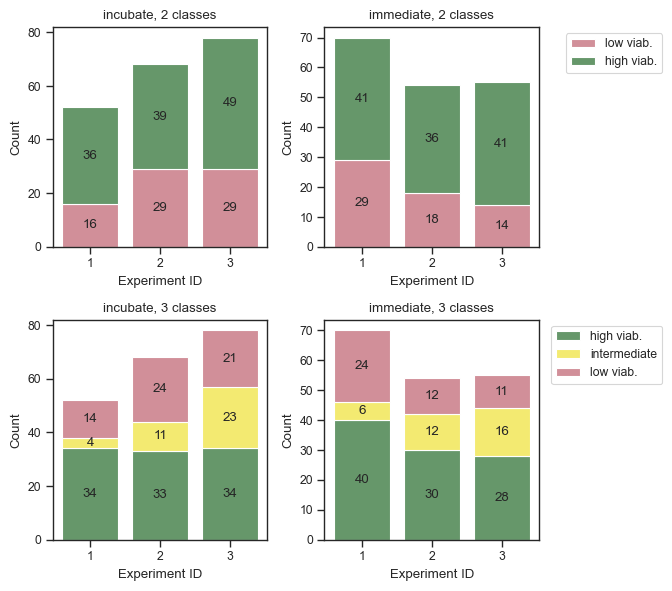

In [135]:
x = 'Experiment ID'
h2 = '2 classes'
h3 = '3 classes'

# Transform Experiment ID into string values
df_incubate_copy[x] = df_incubate_copy[x].astype('str')
df_immediate_copy[x] = df_immediate_copy[x].astype('str')

# Initialize figure
fig, axes = plt.subplots(2, 2, figsize=(7, 6))
axes = axes.flatten()


### Plot histograms
# incubate, 2 classes
sns.histplot(data=df_incubate_copy, x=x, hue=h2, multiple='stack', palette=palette_class, shrink=.8, ax=axes[0], legend=False)

# immediate, 2 classes
sns.histplot(data=df_immediate_copy, x=x, hue=h2, multiple='stack', palette=palette_class, shrink=.8, ax=axes[1])

# incubate, 2 classes
sns.histplot(data=df_incubate_copy, x=x, hue=h3, multiple='stack', palette=palette_class, shrink=.8, ax=axes[2], legend=False)

# immediate, 3 classes
sns.histplot(data=df_immediate_copy, x=x, hue=h3, multiple='stack', palette=palette_class, shrink=.8, ax=axes[3])


### Add numbers corresponding to each bar
def number(axes):
    for p in axes.patches:
    # Coordinates of each bar
        height = p.get_height()
        width = p.get_width()
        x_pos = p.get_x() + width / 2 
        y_pos = p.get_y() + height / 2
        offset = 0.05 
    
        # If bars greater than 0, displays the number of elements corresponding to the bar
        if height > 0:
            axes.text(x_pos, y_pos + offset, f'{int(height)}', ha='center', va='center')

for i in range(4):
    number(axes[i])

### Add titles
axes[0].set_title('incubate, 2 classes')
axes[1].set_title('immediate, 2 classes')
axes[2].set_title('incubate, 3 classes')
axes[3].set_title('immediate, 3 classes')

# Change labels legend
axes[1].legend(['low viab.', 'high viab.'])
axes[3].legend(['high viab.', 'intermediate', 'low viab.'])

sns.move_legend(axes[1], "upper right", bbox_to_anchor=(1.6, 1))
sns.move_legend(axes[3], "upper right", bbox_to_anchor=(1.6, 1))

plt.tight_layout()
plt.savefig(fig_folder / "S9_dataset_description.svg", format='svg', bbox_inches='tight', transparent=False)
plt.show()

In [136]:
df_incubate_copy.groupby('Experiment ID')['3 classes'].value_counts()

Experiment ID  3 classes   
1              high viab.      34
               low viab.       14
               intermediate     4
2              high viab.      33
               low viab.       24
               intermediate    11
3              high viab.      34
               intermediate    23
               low viab.       21
Name: count, dtype: int64

## Save .csv for each feature for GraphPrism plot

In [137]:
def featureToCsvPrism(df, x, y, replace0=(True, 0.001)):
    # x vector sorted and without repetition
    x_values = sorted(df[x].unique())

    # Determine the maximum number of replicates per x_value
    n_replicats = df[x].value_counts().max()

    # Create a new DataFrame with replicates as rows and x values as columns
    new_df = pd.DataFrame(index=list(range(1, n_replicats + 1)), columns=x_values)

    # Populate the new DataFrame with values from `y`
    for x_value in x_values:
        # Take the values of the columns y where column x is equal to x_value, reset index
        filtered_values = df.loc[df[x] == x_value, y].reset_index(drop=True)

        # Add theses values to a new dataframe, 1 column corresponds to the same x_value
        new_df[x_value] = filtered_values.reindex(range(len(new_df)), fill_value=None).values

        # Rename the column with `0` (optional)
        if replace0[0] == True and 0 in new_df.columns:
            new_df.rename(columns={0: replace0[1]}, inplace=True)

        new_df_t = new_df.transpose()

    return new_df_t



def savefeatureToCsvPrism(df, x, cols, folder_name):
    # Create output folder
    folder_csv_features = Path(fig_folder) / folder_name
    createFolder(folder_csv_features)

    # Get unique experiment IDs
    exps = df['Experiment ID'].unique()

    for y in cols:
        # Save data of each experiment independently
        for exp in exps:
            # Filter data for each experiment
            df_filtered = df[df['Experiment ID'] == exp]
            # Format data
            df_prism = featureToCsvPrism(df_filtered, x, y)
            # Save to CSV
            name = f"{y} exp {exp}.csv"
            path = folder_csv_features / name
            df_prism.to_csv(path)
        
        # Save combined data across all experiments
        df_prism = featureToCsvPrism(df, x, y)
        name = f"{y} all.csv"
        path = folder_csv_features / name
        df_prism.to_csv(path)


### Save .csv files for each feature

In [138]:
### Save features .csv independently
x = 'Max temp (°C)'
cols = df_incubate.columns[4:-5]
print(cols)

# For incubate
df = df_incubate.copy()
folder_name = 'csv features incubate'
savefeatureToCsvPrism(df, x, cols, folder_name)

# For immediate
df = df_immediate.copy()
folder_name = 'csv features immediate'
savefeatureToCsvPrism(df, x, cols, folder_name)

print(".csv files have been saved !")

Index(['Path 8bcrop', 'Path segmented', 'Area (um2)', 'Centroid',
       'Perimeter (pix)', 'Solidity', 'Equivalent Diameter (pix)',
       'Circularity', 'Aspect ratio', 'Mean grey value', 'Homogeneity',
       'Energy', 'Correlation'],
      dtype='object')
.csv files have been saved !


### Save .csv files for viability score

In [139]:
### Save metabolic activity independently
x = 'Max temp (°C)'
cols = ['Normalised alb']

df = df_incubate.copy()
folder_name = 'csv viability score incubate'
savefeatureToCsvPrism(df, x, cols, folder_name)

df = df_immediate.copy()
folder_name = 'csv viability score immediate'
savefeatureToCsvPrism(df, x, cols, folder_name)

print(".csv files have been saved !")


.csv files have been saved !


## Description of data

### Plot feature evolution VS day

In [140]:
import re

def featureVSday(fig, ax, df, feature, legend_display=True, palette='rocket'):
    """Plot feature values at day0/1/2 for each row in `df` using a continuous
    colormap mapped to per-row 'Max temp' value. The function will locate
    temperature columns like 'Max temp (°C)', or day-specific columns
    'Max temp (°C)_day0/_day1/_day2' and pick the best available value
    for each row (prefer day2 > day1 > day0). Works with wide or long tables.
    """
    from matplotlib.colors import ListedColormap

    x = [1, 2]

    # column name patterns for temperature
    temp_base_pattern = re.compile(r"max\s*temp", flags=re.I)
    temp_day_pattern = re.compile(r"max\s*temp.*_day([0-2])", flags=re.I)

    # Helper to find candidate temp columns in df
    temp_cols = [c for c in df.columns if temp_base_pattern.search(c)]
    # build mapping day -> column name for day-specific temp columns
    temp_day_cols = {}
    if df.columns.size > 0:
        for c in df.columns:
            m = temp_day_pattern.search(c)
            if m:
                try:
                    day_idx = int(m.group(1))
                    temp_day_cols[day_idx] = c
                except Exception:
                    continue

    # Simpler reliable approach: collect explicit day columns if present
    temp_day0 = next((c for c in df.columns if re.search(r"max\s*temp.*_day0", c, flags=re.I)), None)
    temp_day1 = next((c for c in df.columns if re.search(r"max\s*temp.*_day1", c, flags=re.I)), None)
    temp_day2 = next((c for c in df.columns if re.search(r"max\s*temp.*_day2", c, flags=re.I)), None)
    temp_plain = next((c for c in df.columns if re.search(r"^max\s*temp.*$", c, flags=re.I) and not re.search(r"_day[0-2]", c, flags=re.I)), None)

    # Function to get a representative temperature value for a row
    def get_row_temp(row):
        # Prefer day2, then day1, then day0, then plain, then any temp_cols
        for col in (temp_day2, temp_day1, temp_day0, temp_plain):
            if col is not None and col in row.index:
                val = row.get(col)
                if pd.notna(val):
                    try:
                        return float(val)
                    except Exception:
                        return np.nan
        # fallback: check any column that contains 'max temp'
        for col in temp_cols:
            if col in row.index:
                val = row.get(col)
                if pd.notna(val):
                    try:
                        return float(val)
                    except Exception:
                        continue
        return np.nan

    # Build per-row temperature Series to set colormap limits
    temp_series = df.apply(get_row_temp, axis=1)
    temp_vals = temp_series.dropna().values

    cmap = None; norm = None; sm = None
    if temp_vals.size > 0:
        vmin, vmax = float(temp_vals.min()), float(temp_vals.max())
        if vmin == vmax:
            vmin -= 1.0; vmax += 1.0
        norm = plt.Normalize(vmin=vmin, vmax=vmax)
        # Build cmap from palette input
        try:
            if isinstance(palette, (list, tuple, np.ndarray)):
                cmap = ListedColormap(palette)
            elif isinstance(palette, str):
                try:
                    cmap = sns.color_palette(palette, as_cmap=True)
                except Exception:
                    cmap = plt.get_cmap(palette)
            else:
                try:
                    cmap = sns.color_palette(palette, as_cmap=True)
                except Exception:
                    cmap = plt.cm.viridis
        except Exception:
            cmap = plt.cm.viridis

        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])

    default_color = (0.5, 0.5, 0.5)

    # Helper: generate candidate column names for a feature and day
    def col_candidates(feature_name, day):
        base = re.sub(r"\s*\(.*?\)", "", feature_name).strip()
        candidates = [
            f"{feature_name}_day{day}",
            f"{base}_day{day}",
            f"{feature_name.replace(' ', '_')}_day{day}",
            f"{base.replace(' ', '_')}_day{day}",
        ]
        candidates += [c.lower() for c in candidates]
        seen = set(); out = []
        for c in candidates:
            if c not in seen:
                out.append(c); seen.add(c)
        return out

    # Iterate rows and plot
    for idx, row in df.iterrows():
        y_values = []
        for day in x:
            val = np.nan
            for cand in col_candidates(feature, day):
                if cand in df.columns:
                    val = row.get(cand, np.nan)
                    break
            y_values.append(val)

        if all([pd.isna(v) for v in y_values]):
            continue

        # get temperature for this row
        conc = get_row_temp(row)

        if pd.notna(conc) and cmap is not None and norm is not None:
            color = cmap(norm(conc))
        else:
            color = default_color

        ax.plot(x, y_values, marker='o', color=color, label=(conc if pd.notna(conc) else None))

    # Axis formatting
    ax.set_xlabel('drug exposure time (h)')
    ax.set_ylabel(feature)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['0', '24', '48'])
    ax.grid(True)

    # Add colorbar
    if sm is not None:
        try:
            cbar = fig.colorbar(sm, ax=ax, orientation='vertical', pad=0.02)
            cbar.set_label('Max temp (°C)')
        except Exception:
            pass

    return


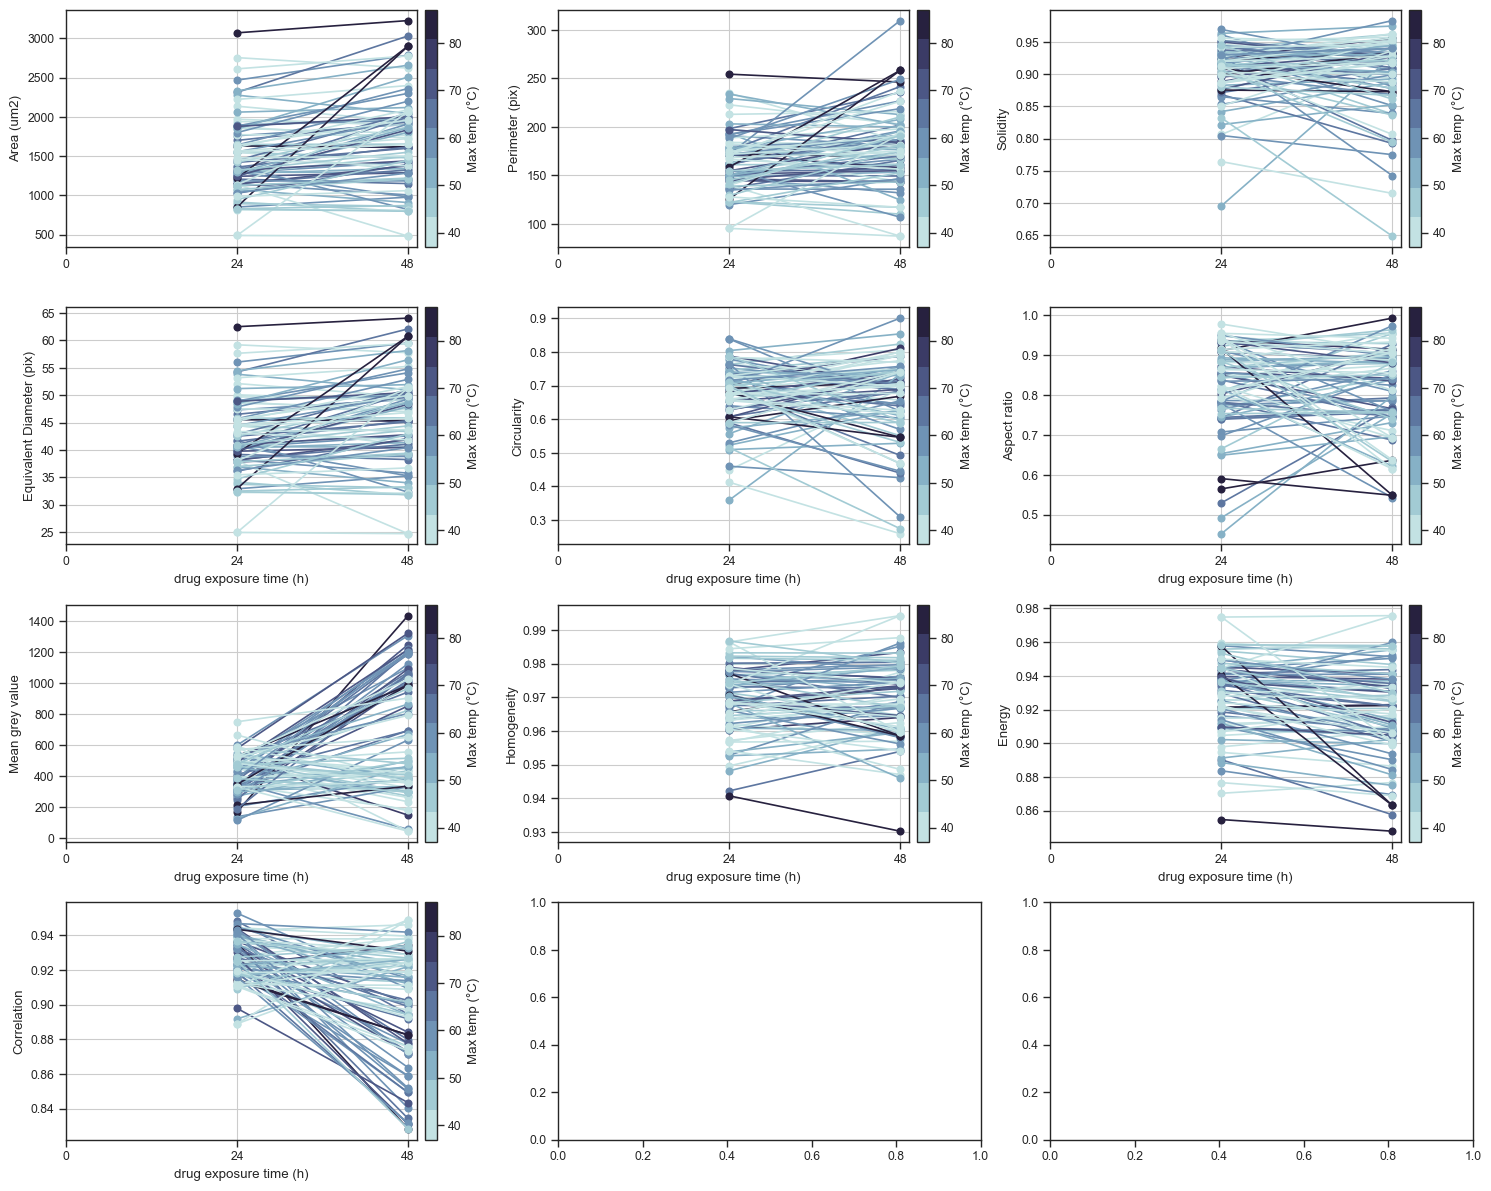

0    46
1    56
2    65
3    60
4    51
Name: Max temp (°C), dtype: int64
count    79.000000
mean     53.291139
std      13.353336
min      37.000000
25%      39.000000
50%      52.000000
75%      61.500000
max      87.000000
Name: Max temp (°C), dtype: float64


In [141]:
import math
features = ['Area (um2)',
   'Perimeter (pix)',
   'Solidity',
   'Equivalent Diameter (pix)',
   'Circularity',
   'Aspect ratio',
   'Mean grey value',
   'Homogeneity',
   'Energy',
   'Correlation'
            ]
df = df_immediate_merged.copy()
n = len(features)
cols = 3
rows = math.ceil(n / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*3))
axes = axes.flatten()


for i, feature in enumerate(features):
    featureVSday(fig, axes[i], df, feature, legend_display=True, palette=palette_drug_incubate)

# Hide x labels for the first line
for ax in axes[:3]:
    ax.set_xlabel('') 

plt.tight_layout()
plt.savefig(fig_folder / "S2 feature VS time incubate.svg", format='svg', bbox_inches='tight', transparent=False)
plt.show()
print(df['Max temp (°C)'].head())
print(df['Max temp (°C)'].describe())

0     168.568542
1     145.396969
2     169.539104
3     147.154328
4     149.396969
         ...    
65    134.083260
66    121.497474
67    133.254833
68    125.254833
69    125.840620
Name: Perimeter (pix)_day1, Length: 70, dtype: float64


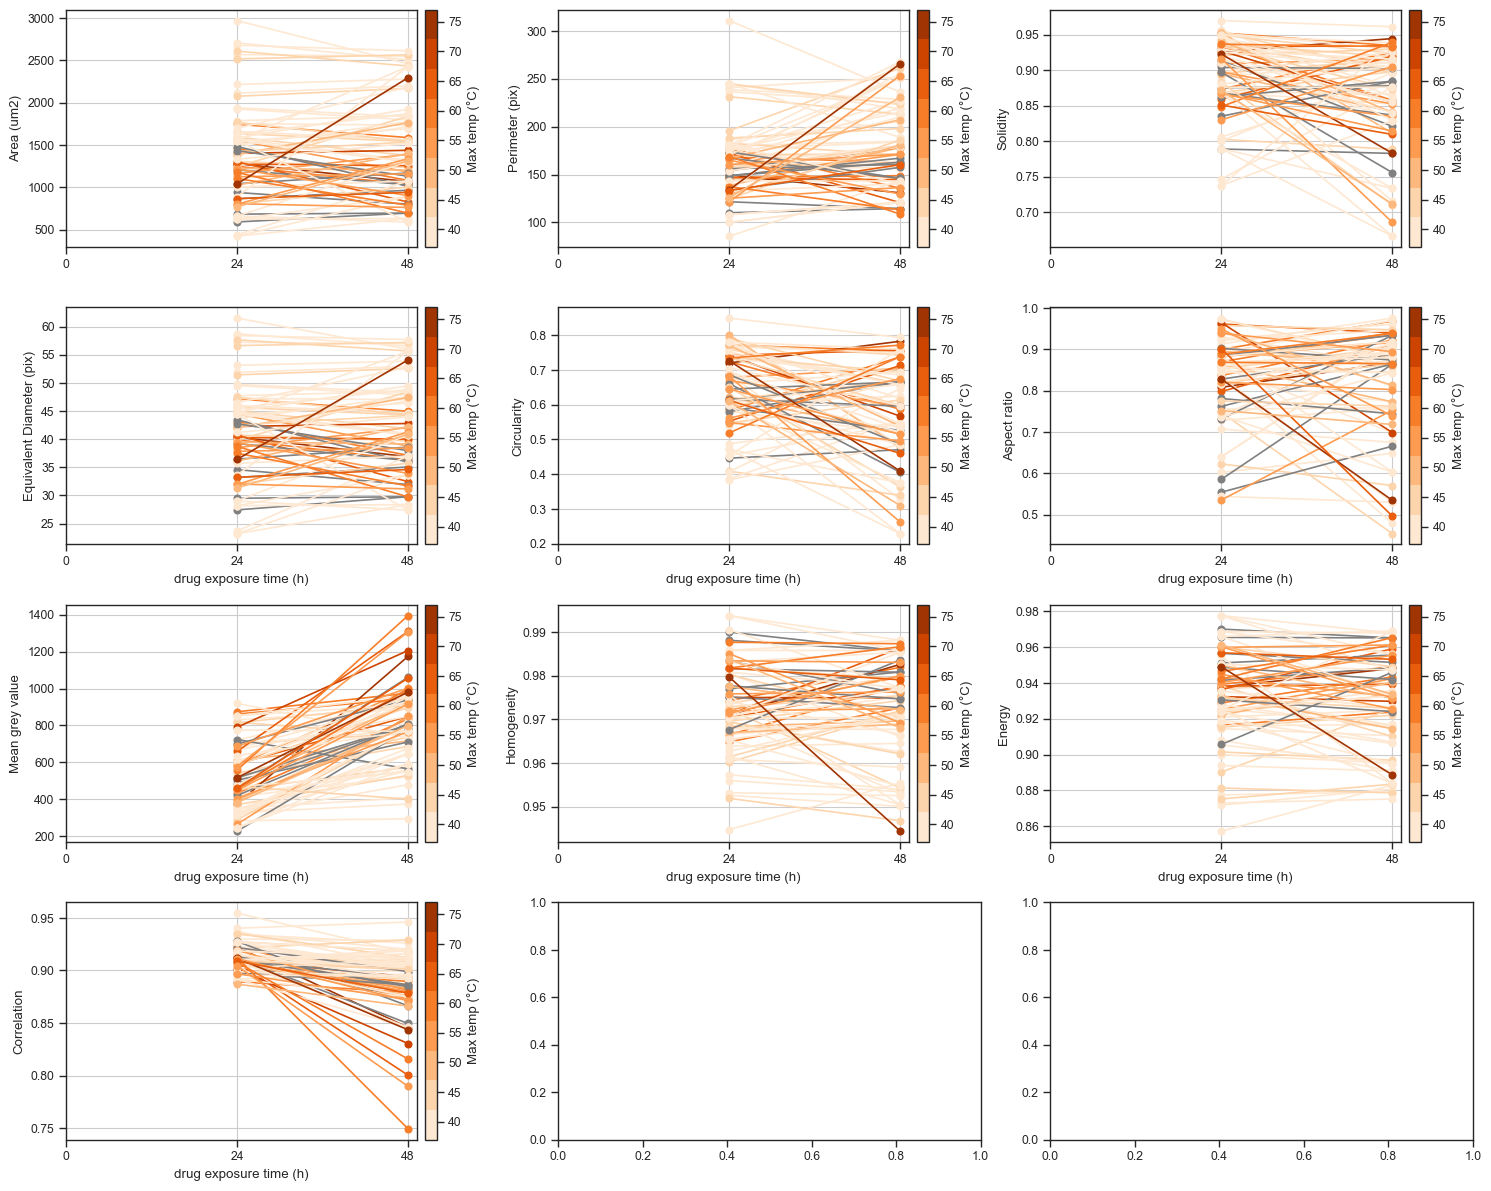

In [142]:
features = [
   'Area (um2)',
   'Perimeter (pix)',
   'Solidity',
   'Equivalent Diameter (pix)',
   'Circularity',
   'Aspect ratio',
   'Mean grey value',
   'Homogeneity',
   'Energy',
   'Correlation'
            ]
df = df_incubate_merged.copy()
print(df['Perimeter (pix)_day1'])
n = len(features)
cols = 3
rows = math.ceil(n / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*3))
axes = axes.flatten()


for i, feature in enumerate(features):
    featureVSday(fig, axes[i], df, feature, legend_display=True, palette=palette_drug_immediate)


# Hide x labels for the first line
for ax in axes[:3]:
    ax.set_xlabel('') 

plt.tight_layout()
plt.savefig(fig_folder / "S2 feature VS time immediate.svg", format='svg', bbox_inches='tight', transparent=False)
plt.show()

### Plot Metabolic activity VS drug

In [143]:
# Define sigmoide equation for the fitting
def sigmoid_normalized(x, IC50, slope):
    return  100 / ( 1 + (IC50 / x) ** slope)

def plot_IC50(fig, ax, df, x, y, title="", sigmoidFit=True, marker='o', marker_col='b', line='-', line_col='b', marker_size=10, line_size=2):
    # For the log representation and fit, change the concentration '0' into a low concentration
    df.loc[:, x] = df[x].replace(0, 0.01)

    ### Plot the data as a scatter plot
    sns.scatterplot(data=df, x=x, y=y, ax=ax,
                    s=marker_size, marker=marker, color=marker_col,  alpha=0.5, legend=False) 

    ### Sigmoid fit
    if sigmoidFit == True:
        X = df[x]
        Y = df[y]

        # For the log representation and fit, change the concentration '0' into a low concentration
        X = X.replace(0, 0.01) 

        # Fit a sigmoid on the data
        ini_param = [np.median(X), -1]
        popt, pcov = curve_fit(sigmoid_normalized, X, Y, p0=ini_param)
        IC50, slope = popt

        # Create points for the fitted curve & plot
        x_fit = np.linspace(min(X), max(X), 10000)
        y_fit = sigmoid_normalized(x_fit, *popt)
        
        # Plot curve
        sns.lineplot(x=x_fit, y=y_fit, 
                            linestyle=line, color=line_col, linewidth=line_size, ax=ax)

        
    ### Graph personalization
    # Define axes limits
    
    axes[0].set_xlim(30, 90)
    axes[1].set_xlim(30, 90)

    # Change graduation
    x_ticks = [0,10,20,30,40,50,60,70,80,90]
    x_labels = ['0'] + [str(l) for l in x_ticks[1::]]
    ax.set_xticks(x_ticks, labels=x_labels)

    ax.set_title(title)

    # Set x & y axis names
    ax.set_xlabel(x)
    ax.set_ylabel(y)        
        
    ax.grid(True)
    
    return IC50, slope, popt, pcov




incubate:
IC50 exp 1 = 52.35317422038352 µM
IC50 exp 2 = 49.55671978647076 µM
IC50 exp 3 = nan µM

immediate:
IC50 exp 1 = 53.00980086017135 µM
IC50 exp 2 = 54.65423033635734 µM
IC50 exp 3 = 49.835404316283096 µM


C:\Users\MMBM-2024-L3\AppData\Local\Temp\ipykernel_27712\2454097372.py:23: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(sigmoid_normalized, X, Y, p0=ini_param)


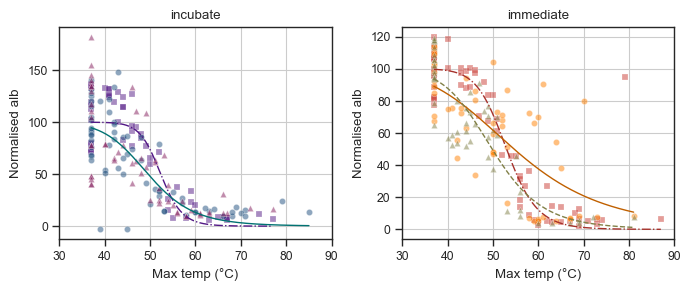

In [155]:
x = 'Max temp (°C)'
y = 'Normalised alb'

# Initialize the figure, 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(7,3))
axes = axes.flatten()

print("incubate:")
df = df_incubate_all_d2.copy()
exps = df['Experiment ID'].unique()

for exp in exps:
    df_filt = df[df['Experiment ID'] == exp]
    kws_dict = kws_dict_incubate[exp]
    marker = kws_dict['marker']
    line = kws_dict['line']
    marker_col = kws_dict['marker_col']
    line_col = kws_dict['line_col']
    marker_size = kws_dict['marker_size']
    line_size = kws_dict['line_size']

    IC50, _, _, _ = plot_IC50(fig, axes[0], df_filt, x, y, title="incubate", sigmoidFit=True, marker=marker, marker_col=marker_col, line=line, line_col=line_col, marker_size=marker_size, line_size=line_size)
    print(f"IC50 exp {exp} = {IC50} µM")

print("\nimmediate:")
df = df_immediate_all_d2.copy()
exps = df['Experiment ID'].unique()

for exp in exps:
    df_filt = df[df['Experiment ID'] == exp]
    kws_dict = kws_dict_immediate[exp]
    marker = kws_dict['marker']
    line = kws_dict['line']
    marker_col = kws_dict['marker_col']
    line_col = kws_dict['line_col']
    marker_size = kws_dict['marker_size']
    line_size = kws_dict['line_size']

    IC50, _, _, _ = plot_IC50(fig, axes[1], df_filt, x, y, title="immediate", sigmoidFit=True, marker=marker, marker_col=marker_col, line=line, line_col=line_col, marker_size=marker_size, line_size=line_size)
    print(f"IC50 exp {exp} = {IC50} µM")
plt.tight_layout()
# Set x-axis limits for both subplots
axes[0].set_xlim(30, 90)
axes[1].set_xlim(30, 90)
plt.show()


### Plot the features VS drug

In [145]:
def sigmoid(x, B, T, IC50, slope):
    return B + (T - B) / (1 + (IC50 / x) ** slope)

In [146]:
def featureVSdrug(df, x, y, ax, limits_y, kws_dict, fit=True, grad=True):
    # Replace concentration 0 for log plot
    df.loc[:, x] = df[x].replace(0, 0.01)

    # Parameters for personalization
    marker = kws_dict['marker']
    line = kws_dict['line']
    marker_col = kws_dict['marker_col']
    line_col = kws_dict['line_col']
    marker_size = kws_dict['marker_size']
    line_size = kws_dict['line_size']

    ### Plot data
    sns.scatterplot(data=df, x=x, y=y, ax=ax,
                    s=marker_size, marker=marker, color=marker_col,  alpha=0.5, legend=False)     
        
    
    ### Sigmoid fit
    if fit == True:
        # Fit the features
        B, T, IC50, slope, pcov = 0,0,0,0,0
        df_filt = df[[x, y]].dropna(subset=[y])
        
        if len(df_filt) != 0:
            X = df_filt[x]
            Y = df_filt[y]
            
            try:
                ini_param = [min(Y), max(Y), np.median(X), 1]
                popt, pcov = curve_fit(sigmoid, X, Y, p0=ini_param)
                B, T, IC50, slope = popt

                # Create points for the fitted curve
                x_fit = np.linspace(min(X), max(X), 10000)
                y_fit = sigmoid(x_fit, *popt)
            
                # Plot
                sns.lineplot(x=x_fit, y=y_fit, 
                            linestyle=line, color=line_col, linewidth=line_size, ax=ax)
                
            except RuntimeError as e:
                pass
        
       
    ### Axes formatting
    
    ax.set_xlim(0.007,110)
    ax.set_xticks([0.01,0.1,1,10,100])
    ax.set_xlabel('Max temp (°C)')
    ax.set_xticklabels(['0', '0.1', '1', '10','100'])
    ax.grid(True)
    
    ax.set_ylabel(y.split('_')[0])
    
    limits_y_key = next((key for key in limits_y if y.startswith(key)), None)
    value = limits_y.get(limits_y_key, None)
    
    if limits_y_key != None:
        ax.set_ylim(value)
    
    if grad == False :
        ax.set_yticklabels([])
        ax.set_ylabel('')
        ax.set_xticklabels([])
        ax.set_xlabel('')

##### Determine y lim
Same ylim for the same features.

In [148]:
feats = ['Area (um2)',
   'Perimeter (pix)',
   'Solidity',
   'Equivalent Diameter (pix)',
   'Circularity',
   'Aspect ratio',
   'Mean grey value',
   'Homogeneity',
   'Energy',
   'Correlation'
        ]

In [153]:
limits_y = {}

for feat in feats:
    if feat != 'Growth' and  feat != 'Grey' and feat != 'DCorrelation_' :
        cols = [f'{feat}_day1', f'{feat}_day1', f'{feat}_day2']
    else:
        cols = [f'{feat}2-0', f'{feat}2-1', f'{feat}1-0']
        
    
    data_incubate = df_incubate_merged[cols].values
    data_immediate = df_immediate_merged[cols].values
    # Combine arrays and coerce to numeric safely using pandas
    import pandas as _pd_for_numeric

    # Flatten multi-dimensional arrays (e.g. shape (n, m)) before converting to Series
    s_inc = _pd_for_numeric.to_numeric(
        _pd_for_numeric.Series(np.asarray(data_incubate).ravel()).astype(str).replace(r"[%\\,]", "", regex=True),
        errors='coerce'
    )
    s_imm = _pd_for_numeric.to_numeric(
        _pd_for_numeric.Series(np.asarray(data_immediate).ravel()).astype(str).replace(r"[%\\,]", "", regex=True),
        errors='coerce'
    )

    data_all = _pd_for_numeric.concat([s_inc, s_imm], ignore_index=True).dropna().to_numpy(dtype=float)
    if data_all.size == 0:
        raise ValueError("No numeric values available to compute min/max")

    # Compute minimal and maximal values from cleaned numeric data
    y_min = np.nanmin(data_all)
    y_max = np.nanmax(data_all)

    # Add a 10% marge around the extreme values
    marge = 0.05 * (y_max - y_min)
    y_min -= marge
    y_max += marge
    y_min = round(y_min,2)
    y_max = round(y_max,2)

    # Save the limits of each feature in a dictionnary
    limits_y[feat] = (y_min,  y_max)

limits_y

{'Area (um2)': (np.float64(282.32), np.float64(3366.18)),
 'Perimeter (pix)': (np.float64(74.45), np.float64(322.0)),
 'Solidity': (np.float64(0.63), np.float64(1.0)),
 'Equivalent Diameter (pix)': (np.float64(21.15), np.float64(66.13)),
 'Circularity': (np.float64(0.19), np.float64(0.93)),
 'Aspect ratio': (np.float64(0.43), np.float64(1.02)),
 'Mean grey value': (np.float64(-23.5), np.float64(1504.2)),
 'Homogeneity': (np.float64(0.93), np.float64(1.0)),
 'Energy': (np.float64(0.84), np.float64(0.98)),
 'Correlation': (np.float64(0.74), np.float64(0.96))}

#### Plot & save figures

C:\Users\MMBM-2024-L3\AppData\Local\Temp\ipykernel_27712\803430728.py:30: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(sigmoid, X, Y, p0=ini_param)
C:\Users\MMBM-2024-L3\AppData\Local\Temp\ipykernel_27712\803430728.py:30: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(sigmoid, X, Y, p0=ini_param)
C:\Users\MMBM-2024-L3\AppData\Local\Temp\ipykernel_27712\803430728.py:30: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(sigmoid, X, Y, p0=ini_param)
C:\Users\MMBM-2024-L3\AppData\Local\Temp\ipykernel_27712\803430728.py:30: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(sigmoid, X, Y, p0=ini_param)
C:\Users\MMBM-2024-L3\AppData\Local\Temp\ipykernel_27712\803430728.py:30: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(sigmoid, X, Y, p0=ini_param)
C:\Users\MMBM-2

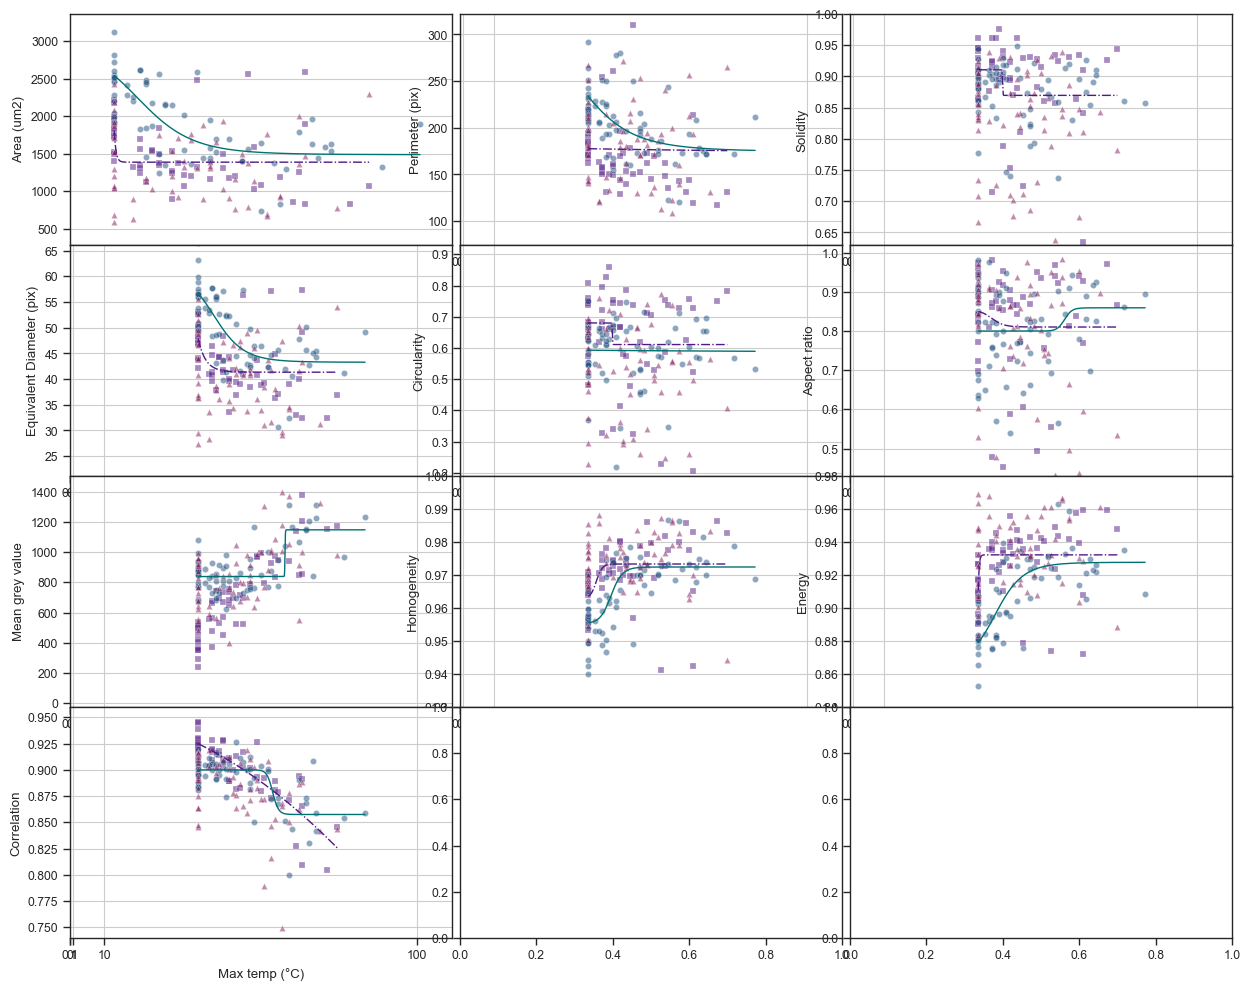

In [156]:
y_list = [ 
  'Area (um2)',
   'Perimeter (pix)',
   'Solidity',
   'Equivalent Diameter (pix)',
   'Circularity',
   'Aspect ratio',
   'Mean grey value',
   'Homogeneity',
   'Energy',
   'Correlation'
    ]

# Plot incubate data
df = df_incubate_all_d2.copy()
kws_dict = kws_dict_incubate
exps = df['Experiment ID'].unique()
n = len(features)
cols = 3
rows = math.ceil(n / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*3))
axes = axes.flatten()


# Plot feature vs drug for each feature
for i, y in enumerate(y_list):
    for exp in exps:
        kws_dict_exp = kws_dict[exp]
        df_filt = df[df['Experiment ID'] == exp]
        featureVSdrug(df_filt, x, y, axes[i], limits_y, kws_dict_exp, fit=True, grad=True)

plt.subplots_adjust(hspace=0, wspace=0.02)
axes[0].set_xlim(30, 90)
plt.show()

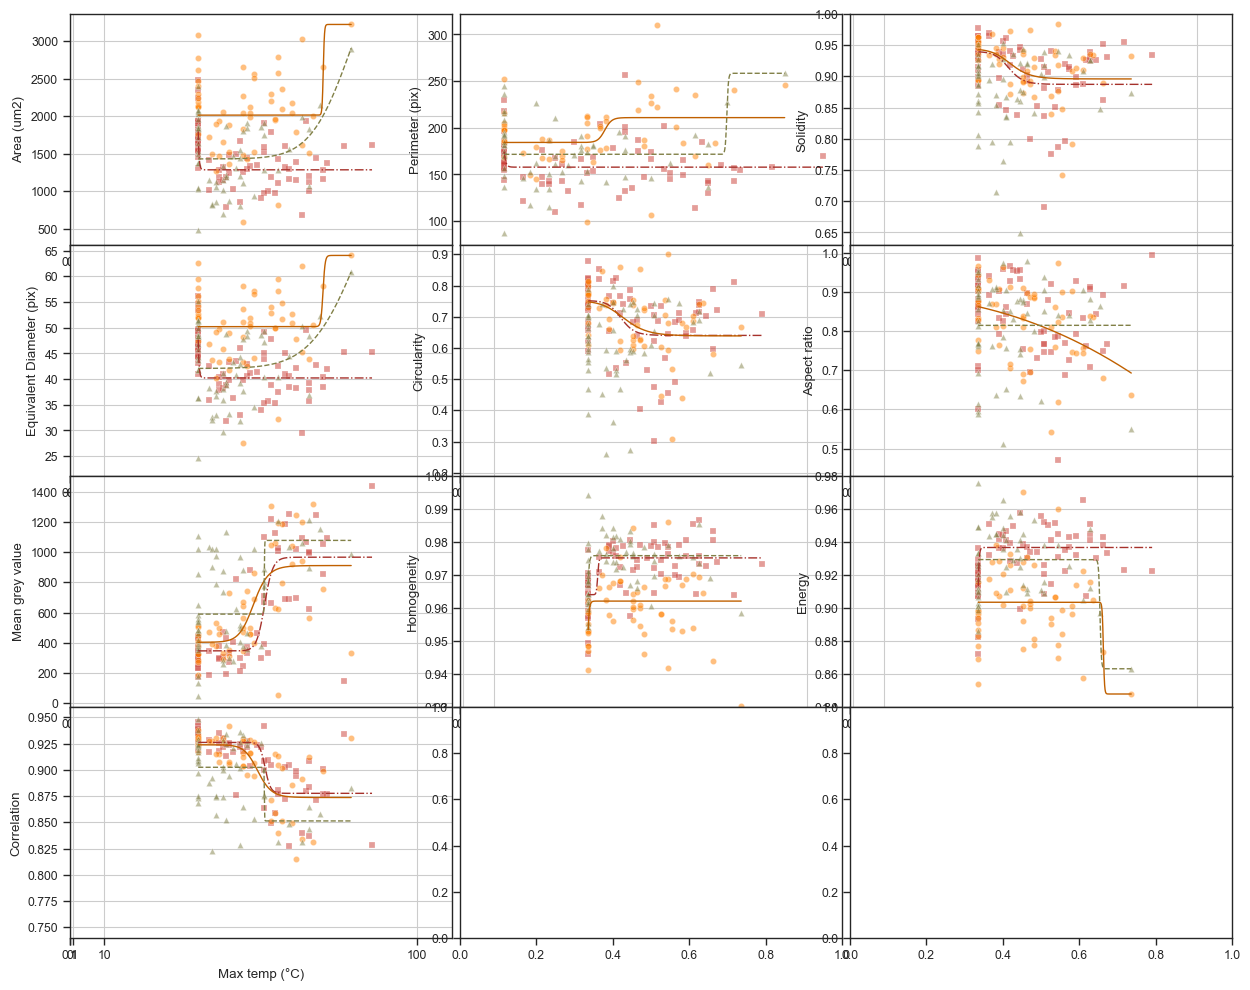

In [158]:
# Plot immediate data
df = df_immediate_all_d2.copy()
kws_dict = kws_dict_immediate
exps = df['Experiment ID'].unique()

n = len(features)
cols = 3
rows = math.ceil(n / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*3))
axes = axes.flatten()


for i, y in enumerate(y_list):
    for exp in exps:
        kws_dict_exp = kws_dict[exp]
        df_filt = df[df['Experiment ID'] == exp]
        featureVSdrug(df_filt, x, y, axes[i], limits_y, kws_dict_exp, fit=True, grad=True)

plt.subplots_adjust(hspace=0, wspace=0.02)
axes[1].set_xlim(30, 90)
plt.show()

### Histogram feature VS class

In [159]:
df_incubate_all_d2.columns

Index(['Name', 'Index', 'Wells', 'multiple', 'Path 8bcrop', 'Path segmented',
       'Area (um2)', 'Centroid', 'Perimeter (pix)', 'Solidity',
       'Equivalent Diameter (pix)', 'Circularity', 'Aspect ratio',
       'Mean grey value', 'Homogeneity', 'Energy', 'Correlation',
       'Normalised alb', 'Max temp (°C)', 'Sheet', 'Experiment ID', 'Label'],
      dtype='object')

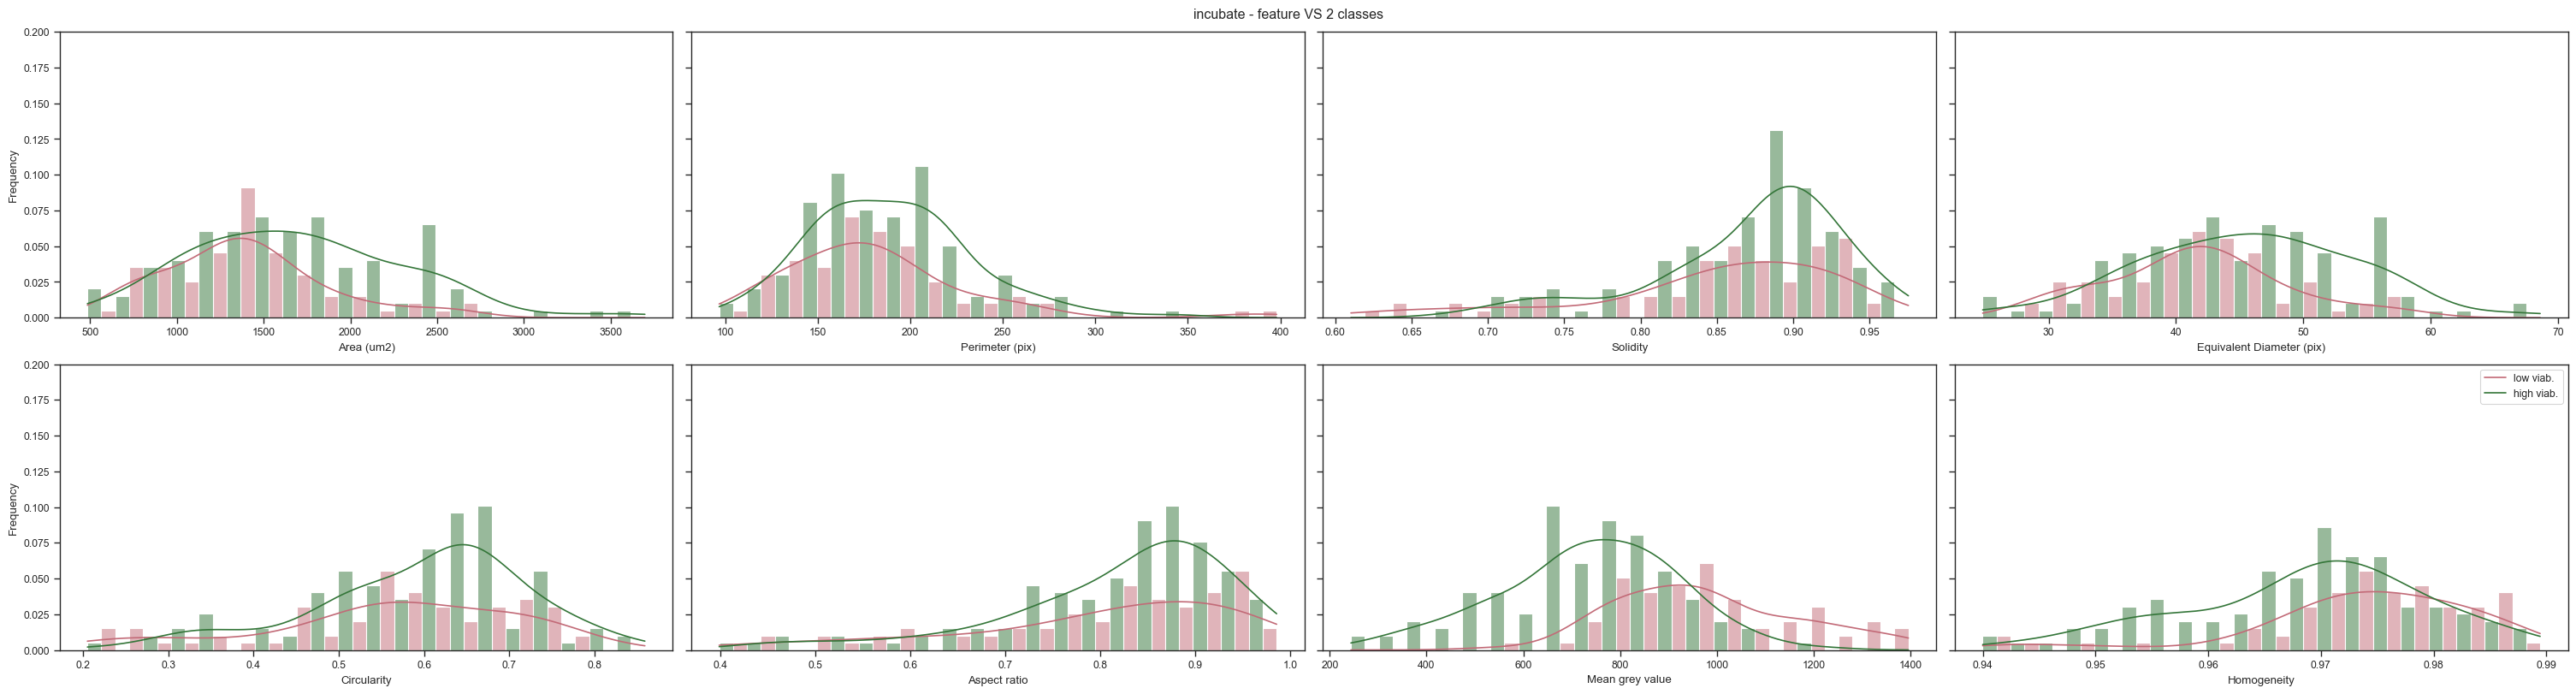

In [161]:
df = df_incubate_copy.copy()
n_class = 2

#cols = [i for i in features if i.endswith('day2')]
cols = [
    'Area (um2)',
   'Perimeter (pix)',
   'Solidity',
   'Equivalent Diameter (pix)',
   'Circularity',
   'Aspect ratio',
   'Mean grey value',
   'Homogeneity',
   'Energy',
   'Correlation'
            ]


fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(30, 8), constrained_layout=True, sharey=True)
axes = axes.flatten()

fig.suptitle(f'incubate - feature VS {n_class} classes')


labels = df[f'{n_class} classes'].unique()

for idx, col in enumerate(cols):
    if idx < len(axes):
        sns.histplot(data=df, x=col, hue=f'{n_class} classes', palette=palette_class, multiple='dodge', legend=False,
                     shrink=1, ax=axes[idx], bins=20, stat='probability', kde=True
                     )
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')

axes[-1].legend(['low viab.', 'high viab.'])
axes[0].set_ylim(0, 0.2)

plt.savefig(fig_folder / "4A histogram feature vs class incubate.svg", format='svg', bbox_inches='tight', transparent=True)

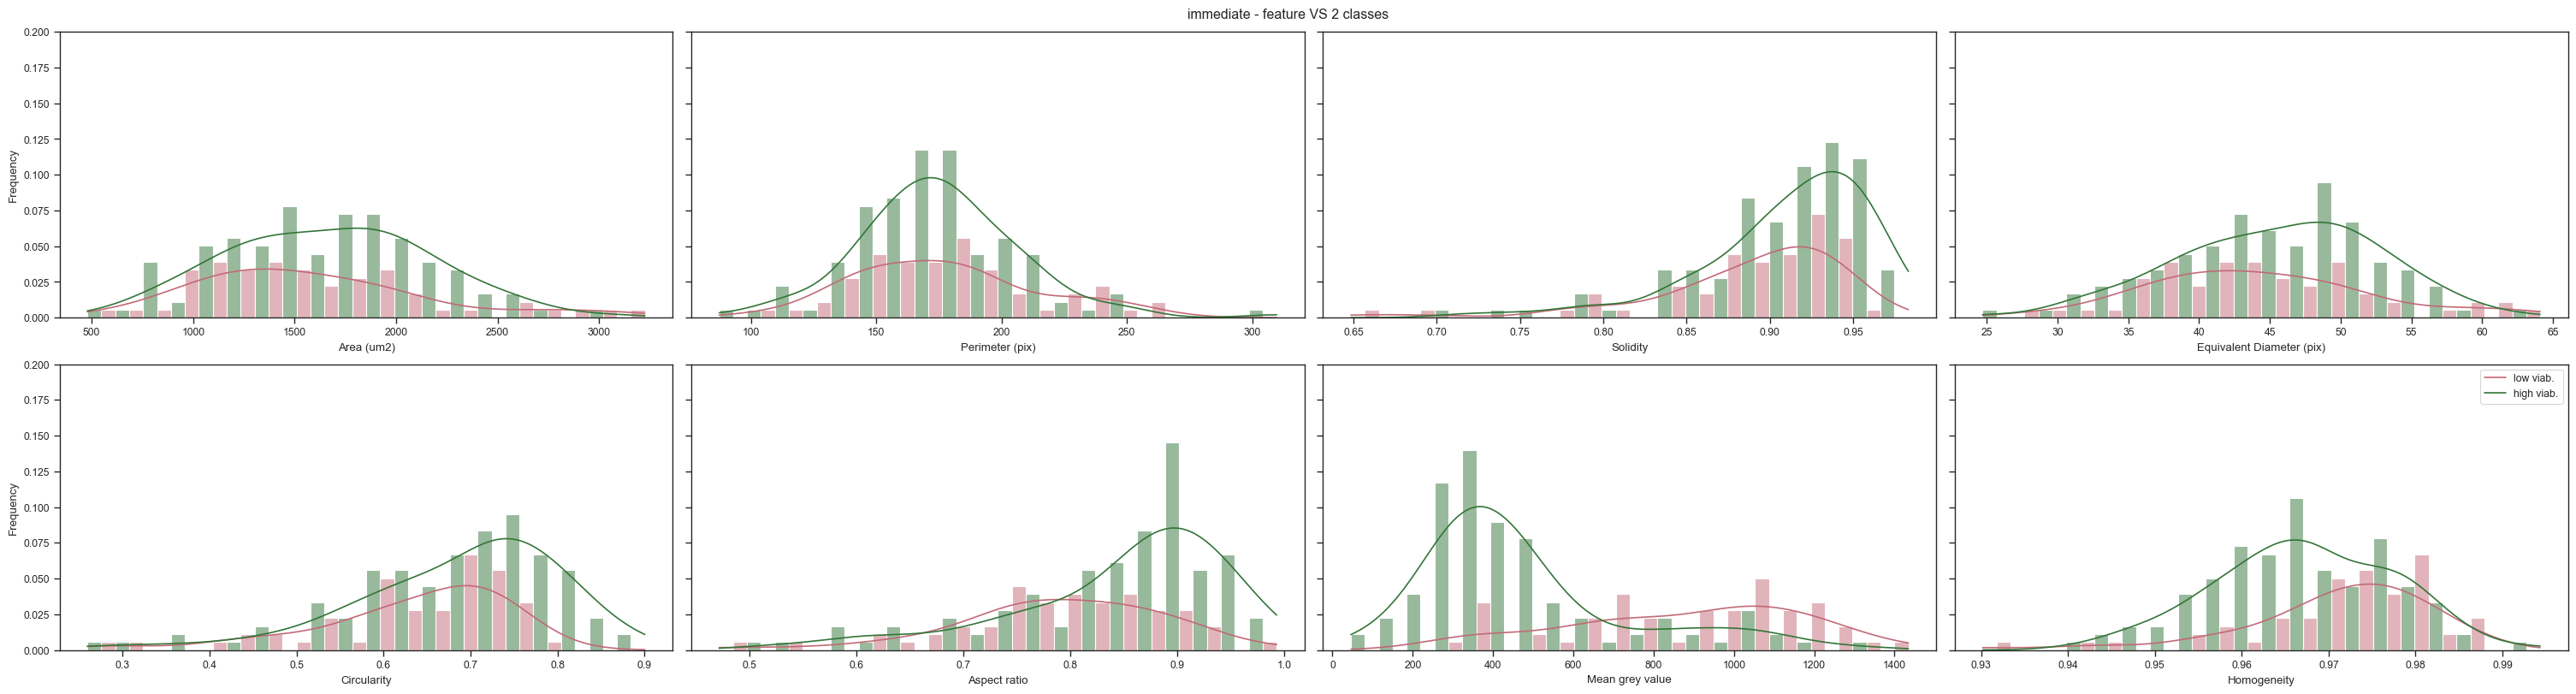

In [162]:
X_2classes = df_immediate_copy['2 classes']
df = df_immediate_copy.copy()

#cols = [i for i in features if i.endswith('day2')]
cols = ['Area (um2)',
   'Perimeter (pix)',
   'Solidity',
   'Equivalent Diameter (pix)',
   'Circularity',
   'Aspect ratio',
   'Mean grey value',
   'Homogeneity',
   'Energy',
   'Correlation']
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(30, 8), constrained_layout=True, sharey=True)
axes = axes.flatten()
fig.suptitle('immediate - feature VS 2 classes')

labels = df_incubate_copy['2 classes'].unique()

for idx, col in enumerate(cols):
    if idx < len(axes):
        sns.histplot(data=df, x=col, hue='2 classes', palette=palette_class, multiple='dodge', legend=False,
                     shrink=1, ax=axes[idx], bins=20, stat='probability', kde=True
                     )
        
        
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')

axes[-1].legend(['low viab.', 'high viab.'])
axes[0].set_ylim(0, 0.2)

plt.savefig(fig_folder / "4C histogram feature vs class immediate.svg", format='svg', bbox_inches='tight', transparent=True)

## Other representations

### Grey level VS viability vs drug

C:\Users\MMBM-2024-L3\AppData\Local\Temp\ipykernel_27712\536924829.py:21: UserWarning: 
The palette list has fewer values (8) than needed (39) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(data=df, x=x, y=y[int(i/2)], hue=hue, palette=palette_drug_incubate, ax=axes[i], legend=False)
C:\Users\MMBM-2024-L3\AppData\Local\Temp\ipykernel_27712\536924829.py:21: UserWarning: 
The palette list has fewer values (8) than needed (39) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(data=df, x=x, y=y[int(i/2)], hue=hue, palette=palette_drug_incubate, ax=axes[i], legend=False)
C:\Users\MMBM-2024-L3\AppData\Local\Temp\ipykernel_27712\536924829.py:21: UserWarning: 
The palette list has fewer values (8) than needed (39) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(data=df, x=x, y=y[int(i/2)], hue=hue, palette=palette_drug_incubate, ax=axes[i], legend=False)
C:\Users\MMBM-2024-L3\AppData\Local\Temp\ipykernel_2771

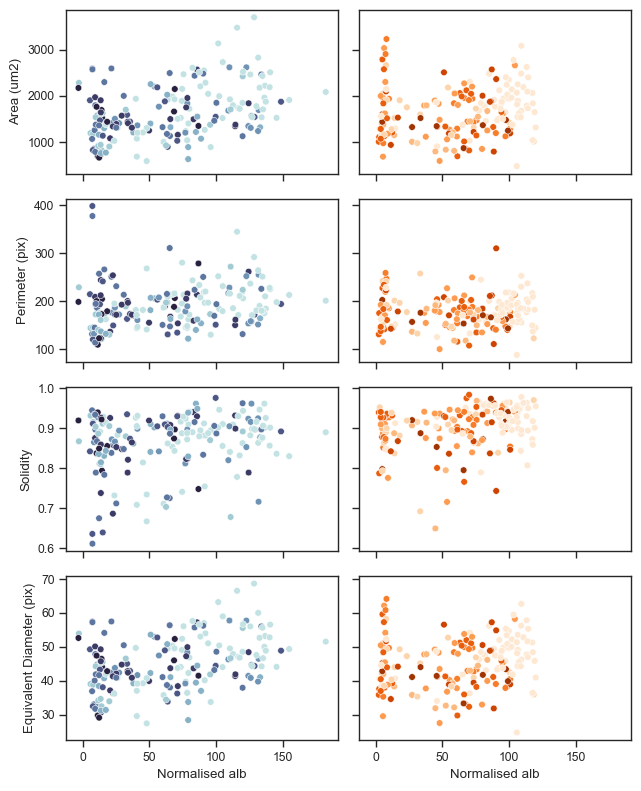

In [164]:
x = 'Normalised alb'
y = ['Area (um2)',
   'Perimeter (pix)',
   'Solidity',
   'Equivalent Diameter (pix)',
   'Circularity',
   'Aspect ratio',
   'Mean grey value',
   'Homogeneity',
   'Energy',
   'Correlation']
hue = 'Max temp (°C)'

fig, axes = plt.subplots(4, 2, figsize=(6.5, 8), sharex=True, sharey='row')
axes = axes.flatten()

df = df_incubate_all_d2.copy()
df[hue] = pd.Categorical(df[hue], ordered=True)
for i in range(8):
    if i%2==0:
        sns.scatterplot(data=df, x=x, y=y[int(i/2)], hue=hue, palette=palette_drug_incubate, ax=axes[i], legend=False)

df = df_immediate_all_d2.copy()
df[hue] = pd.Categorical(df[hue], ordered=True)
for i in range(8):
    if i%2!=0:
        sns.scatterplot(data=df, x=x, y=y[int(i/2)], hue=hue, palette=palette_drug_immediate, ax=axes[i], legend=False)

plt.tight_layout()
plt.savefig(fig_folder / "S8 features VS viability vs drug.svg", format='svg', bbox_inches='tight', transparent=True)


C:\Users\MMBM-2024-L3\AppData\Local\Temp\ipykernel_27712\1966941526.py:3: UserWarning: 
The palette list has fewer values (8) than needed (38) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(data=df, x=x, hue=hue, palette=palette_drug_incubate, ax=axes, legend=True)
C:\Users\MMBM-2024-L3\AppData\Local\Temp\ipykernel_27712\1966941526.py:10: UserWarning: 
The palette list has fewer values (8) than needed (38) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(data=df, x=x, hue=hue, palette=palette_drug_immediate, ax=axes, legend=True)


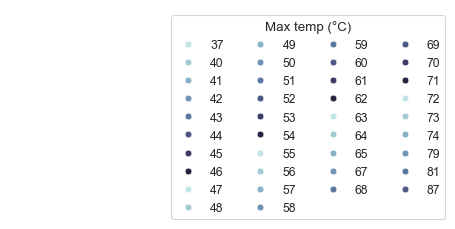

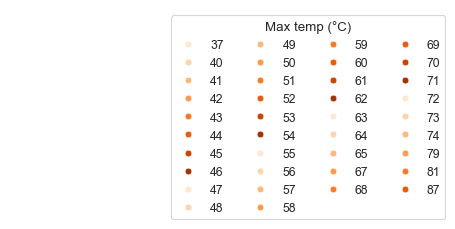

In [165]:

# Legend
fig, axes = plt.subplots(1, 1, figsize=(2,2))
sns.scatterplot(data=df, x=x, hue=hue, palette=palette_drug_incubate, ax=axes, legend=True)
sns.move_legend(axes, loc='upper left', bbox_to_anchor=(1, 1), ncol=4)
axes.axis('off')
plt.savefig(fig_folder / "S8 legend1.svg", format='svg', bbox_inches='tight', transparent=True)

# Legend
fig, axes = plt.subplots(1, 1, figsize=(2,2))
sns.scatterplot(data=df, x=x, hue=hue, palette=palette_drug_immediate, ax=axes, legend=True)
sns.move_legend(axes, loc='upper left', bbox_to_anchor=(1, 1), ncol=4
                )
axes.axis('off')
plt.savefig(fig_folder / "S8 legend2.svg", format='svg', bbox_inches='tight', transparent=True)


<Axes: xlabel='Max temp (°C)', ylabel='Normalised alb'>

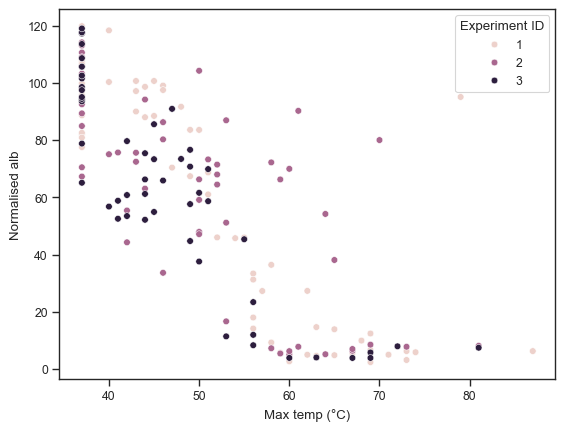

In [166]:
x = 'Max temp (°C)'
y = 'Normalised alb'
sns.scatterplot(x=x, y=y,
        hue = 'Experiment ID',
             data=df,
             markers=True)


###

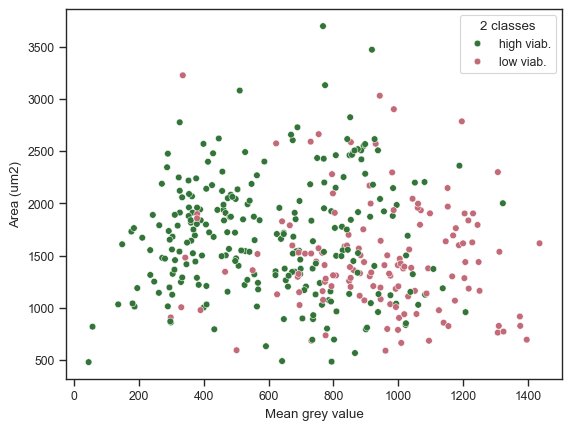

In [167]:
x = 'Mean grey value'
y = 'Area (um2)'
hue = '2 classes'

scatter = sns.scatterplot(data=df_incubate_copy, x=x, y=y, hue=hue, palette=palette_class)
scatter = sns.scatterplot(data=df_immediate_copy,  x=x, y=y, hue=hue, palette=palette_class, legend=False)

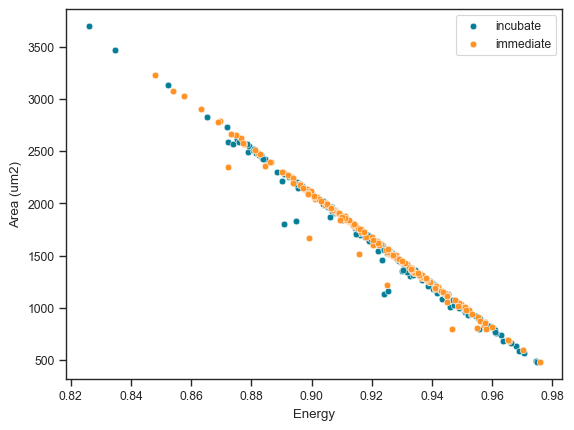

In [168]:
x = 'Energy'
y = 'Area (um2)'

scatter = sns.scatterplot(data=df_incubate_copy, x=x, y=y, color=palette_cells['incubate'], label='incubate')
scatter = sns.scatterplot(data=df_immediate_copy, x=x, y=y, color=palette_cells['immediate'], label='immediate')

<Axes: xlabel='Normalised alb', ylabel='Area (um2)'>

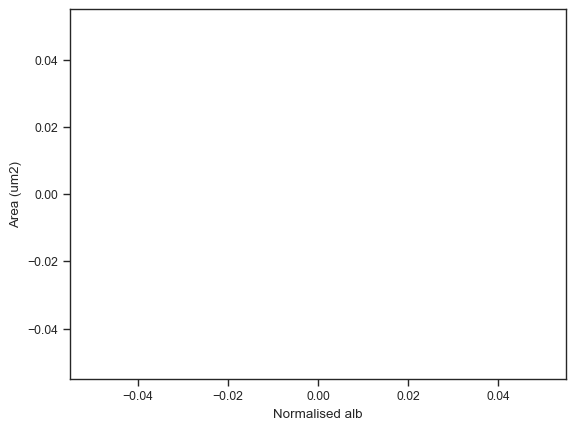

In [170]:
x = 'Normalised alb'
y = 'Area (um2)'

sns.regplot(data=df_incubate_all_d2[df_incubate_copy['Max temp (°C)']==0], x=x, y=y, color=palette_cells['incubate'], label='incubate')
sns.regplot(data=df_immediate_all_d2[df_immediate_copy['Max temp (°C)']==0], x=x, y=y, color=palette_cells['immediate'], label='immediate')

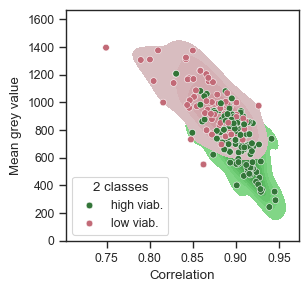

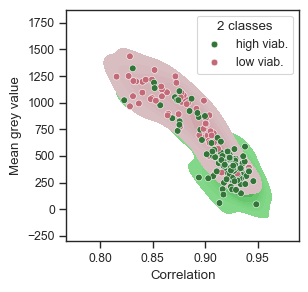

In [171]:
x = 'Correlation'
y = 'Mean grey value'
classe = '2 classes'

df = df_incubate_copy.copy()

fig, ax = plt.subplots(figsize=(3, 3))
sns.kdeplot(data=df, x=x, y=y, hue=classe,
    fill=True, palette=palette_class)
scatter = sns.scatterplot(data=df, x=x, y=y, hue=classe, palette=palette_class)

df = df_immediate_copy.copy()

fig, ax = plt.subplots(figsize=(3, 3))
sns.kdeplot(data=df, x=x, y=y, hue=classe,
    fill=True, palette=palette_class, ax=ax
)
scatter = sns.scatterplot(data=df, x=x, y=y, hue=classe, palette=palette_class)

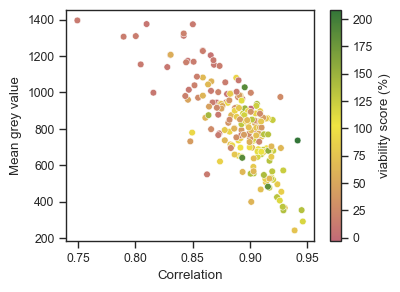

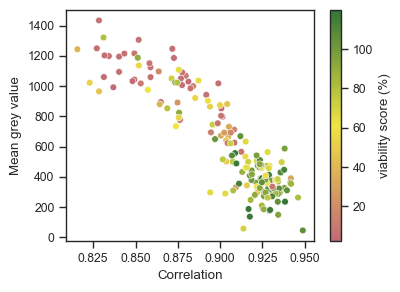

In [172]:
### Color palette
color_start = (194/255, 106/255, 119/255)  # reddish color
color_middle = (240/255, 228/255, 66/255)  # yellowish color
color_end = (51/255, 117/255, 56/255)  # greenish color

# Create a custom colormap that transitions through the three colors
continuous_cmap = LinearSegmentedColormap.from_list("custom_palette", [color_start, color_middle, color_end])


x = 'Correlation'
y = 'Mean grey value'
viab = 'Normalised alb'

df = df_incubate_copy.copy()

fig, ax = plt.subplots(figsize=(4, 3))
scatter = sns.scatterplot(data=df, x=x, y=y, hue=viab, palette=continuous_cmap, legend=None, ax=ax)
# Add a color bar to indicate the continuous values
norm = plt.Normalize(df[viab].min(), df[viab].max())
sm = plt.cm.ScalarMappable(cmap=continuous_cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('viability score (%)')


df = df_immediate_copy.copy()

fig, ax = plt.subplots(figsize=(4, 3))
scatter = sns.scatterplot(data=df, x=x, y=y, hue=viab, palette=continuous_cmap, legend=None, ax=ax)
# Add a color bar to indicate the continuous values
norm = plt.Normalize(df[viab].min(), df[viab].max())
sm = plt.cm.ScalarMappable(cmap=continuous_cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax = ax)
cbar.set_label('viability score (%)')